In [2]:
import pandas as pd


In [3]:
count = sum(1 for _ in open('postings.csv'))
print("Total rows in file (including header):", count)

Total rows in file (including header): 3383602


In [5]:
cols = ['job_id', 'company_name', 'title', 'description', 'location',
        'formatted_experience_level', 'formatted_work_type', 'remote_allowed',
        'min_salary', 'med_salary', 'max_salary', 'pay_period',
        'normalized_salary', 'currency', 'views', 'applies', 'listed_time']

chunks = []
for chunk in pd.read_csv('postings.csv', usecols=cols, chunksize=200000):
    mask = chunk['title'].str.contains('data analyst', case=False, na=False)
    chunks.append(chunk[mask])

df = pd.concat(chunks, ignore_index=True)
print("Total Data Analyst jobs found:", len(df))

Total Data Analyst jobs found: 408


In [7]:
total_rows_scanned = 0
chunk_count = 0
for chunk in pd.read_csv('postings.csv', usecols=['job_id','title'], chunksize=200000):
    total_rows_scanned += len(chunk)
    chunk_count += 1

print("Total chunks (trips):", chunk_count)
print("Total rows scanned:", total_rows_scanned)

Total chunks (trips): 1
Total rows scanned: 123849


In [10]:
skills = {
    'sql': r'\bsql\b',
    'excel': r'\bexcel\b',
    'python': r'\bpython\b',
    'tableau': r'\btableau\b',
    'power_bi': r'power\s?bi',
    'r_lang': r'\br programming\b|\br studio\b|\brstudio\b',
    'looker': r'\blooker\b',
    'aws': r'\baws\b',
    'azure': r'\bazure\b',
    'statistics': r'\bstatistic',
    'machine_learning': r'machine learning|\bml\b',
    'etl': r'\betl\b',
    'spark': r'\bspark\b',
}

desc = df['description'].fillna('').str.lower()

for name, pattern in skills.items():
    df[name] = desc.str.contains(pattern, regex=True, na=False).astype(int)

print(df[list(skills.keys())].sum().sort_values(ascending=False))

sql                 246
excel               147
python              139
statistics          125
power_bi             85
tableau              84
machine_learning     57
aws                  32
etl                  27
azure                20
looker               16
spark                13
r_lang                3
dtype: int64


In [11]:
sal = df[df['normalized_salary'].notna()].copy()
print("Jobs with salary data:", len(sal))
print("Average salary:", round(sal['normalized_salary'].mean()))
print("Median salary:", round(sal['normalized_salary'].median()))

Jobs with salary data: 130
Average salary: 105312
Median salary: 99920


In [13]:
skill_list = ['sql','excel','python','tableau','power_bi','statistics','machine_learning']

for s in skill_list:
    with_skill = sal[sal[s]==1]['normalized_salary'].mean()
    without_skill = sal[sal[s]==0]['normalized_salary'].mean()
    count_with = (sal[s]==1).sum()
    print(f"{s:20s} WITH: ${with_skill:,.0f} (n={count_with})   WITHOUT: ${without_skill:,.0f}")

sql                  WITH: $111,815 (n=81)   WITHOUT: $94,561
excel                WITH: $101,811 (n=61)   WITHOUT: $108,407
python               WITH: $105,198 (n=39)   WITHOUT: $105,361
tableau              WITH: $110,970 (n=44)   WITHOUT: $102,417
power_bi             WITH: $101,836 (n=42)   WITHOUT: $106,971
statistics           WITH: $106,862 (n=51)   WITHOUT: $104,311
machine_learning     WITH: $95,686 (n=17)   WITHOUT: $106,760


In [14]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate job_ids:", df['job_id'].duplicated().sum())

Duplicate rows: 0
Duplicate job_ids: 0


In [15]:
print(df.isnull().sum())

job_id                          0
company_name                    2
title                           0
description                     0
max_salary                    295
pay_period                    278
location                        0
views                           6
med_salary                    391
min_salary                    295
formatted_work_type             0
applies                       157
remote_allowed                259
formatted_experience_level    117
listed_time                     0
currency                      278
normalized_salary             278
sql                             0
excel                           0
python                          0
tableau                         0
power_bi                        0
r_lang                          0
looker                          0
aws                             0
azure                           0
statistics                      0
machine_learning                0
etl                             0
spark         

In [18]:

print(sal['normalized_salary'].describe())

count       130.000000
mean     105311.853308
std       32559.493983
min       47840.000000
25%       83475.000000
50%       99920.000000
75%      125000.000000
max      222650.000000
Name: normalized_salary, dtype: float64


In [19]:
print(df.dtypes)


job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
remote_allowed                float64
formatted_experience_level     object
listed_time                   float64
currency                       object
normalized_salary             float64
sql                             int64
excel                           int64
python                          int64
tableau                         int64
power_bi                        int64
r_lang                          int64
looker                          int64
aws                             int64
azure                           int64
statistics  

In [21]:
import re

def extract_state(location):
    if pd.isna(location):
        return 'Unknown'
    match = re.search(r',\s*([A-Z]{2})\b', str(location))
    if match:
        return match.group(1)
    elif location.strip() == 'United States':
        return 'Remote/Nationwide'
    else:
        return 'Other'

df['state'] = df['location'].apply(extract_state)

print(df['state'].value_counts().head(15))

state
Other                80
Remote/Nationwide    57
TX                   39
CA                   36
VA                   29
FL                   22
NY                   17
NC                   12
NJ                   12
GA                   10
IL                    9
MN                    8
DC                    6
PA                    6
AZ                    5
Name: count, dtype: int64


In [22]:
import sqlite3

conn = sqlite3.connect('data_analyst_jobs.db')
df.to_sql('postings', conn, if_exists='replace', index=False)

query = """
SELECT 
    CASE WHEN sql = 1 THEN 'Mentions SQL' ELSE 'No SQL' END as sql_mentioned,
    COUNT(*) as job_count,
    ROUND(AVG(normalized_salary)) as avg_salary
FROM postings
WHERE normalized_salary IS NOT NULL
GROUP BY sql
"""

result = pd.read_sql(query, conn)
print(result)

  sql_mentioned  job_count  avg_salary
0        No SQL         49     94561.0
1  Mentions SQL         81    111815.0


In [23]:
query2 = """
SELECT location, COUNT(*) as job_count
FROM postings
GROUP BY location
ORDER BY job_count DESC
LIMIT 10
"""
print(pd.read_sql(query2, conn))

                          location  job_count
0                    United States         57
1                     New York, NY         12
2                     Richmond, VA          8
3                        Plano, TX          7
4  New York City Metropolitan Area          7
5                   Washington, DC          6
6                San Francisco, CA          6
7                      Atlanta, GA          6
8                        Tampa, FL          5
9                    San Diego, CA          5


In [24]:
query3 = """
SELECT sql, python, tableau, power_bi, COUNT(*) as job_count
FROM postings
GROUP BY sql, python, tableau, power_bi
ORDER BY job_count DESC
LIMIT 10
"""
print(pd.read_sql(query3, conn))

   sql  python  tableau  power_bi  job_count
0    0       0        0         0        122
1    1       0        0         0         77
2    1       1        0         0         72
3    1       1        1         0         19
4    1       1        1         1         19
5    1       0        1         1         18
6    1       0        0         1         15
7    0       0        0         1         13
8    1       0        1         0         13
9    1       1        0         1         13


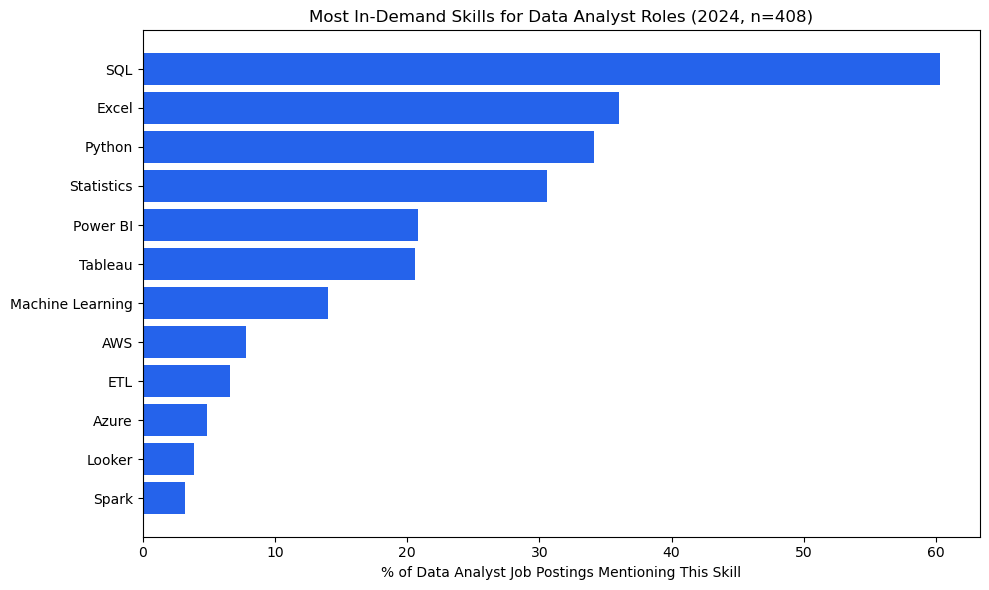

In [26]:
import matplotlib.pyplot as plt

skills_cols = ['sql','excel','python','statistics','power_bi','tableau','machine_learning','etl','aws','azure','looker','spark']
skill_labels = ['SQL','Excel','Python','Statistics','Power BI','Tableau','Machine Learning','ETL','AWS','Azure','Looker','Spark']
counts = df[skills_cols].sum().values
pct = (counts / len(df) * 100).round(1)

order = counts.argsort()[::-1]
sorted_labels = [skill_labels[i] for i in order]
sorted_pct = pct[order]

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(sorted_labels[::-1], sorted_pct[::-1], color='#2563eb')
ax.set_xlabel('% of Data Analyst Job Postings Mentioning This Skill')
ax.set_title('Most In-Demand Skills for Data Analyst Roles (2024, n=408)')
plt.tight_layout()
plt.savefig('skill_demand_chart.png', dpi=150)
plt.show()

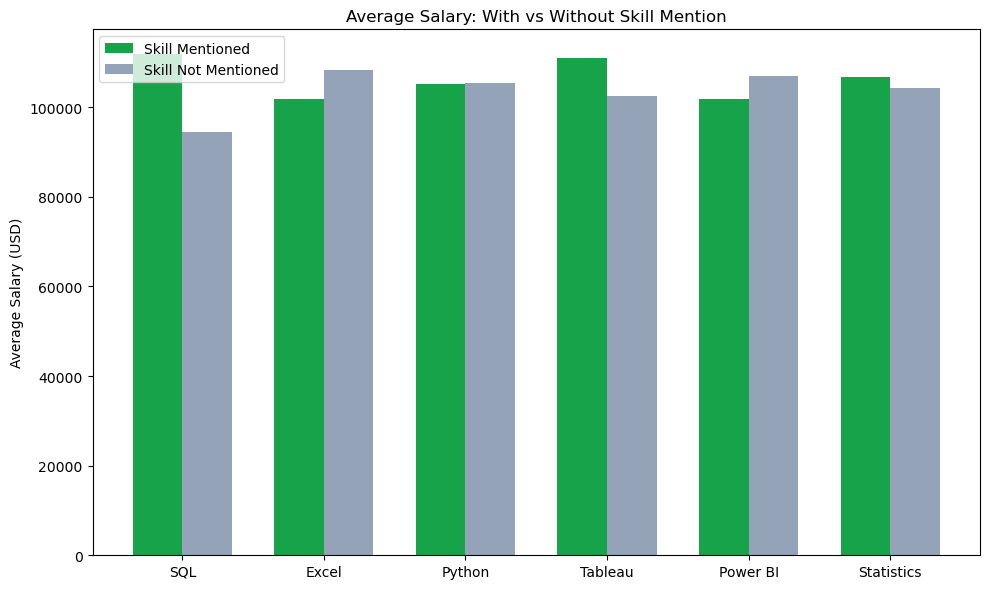

In [27]:
import numpy as np

compare_skills = ['sql','excel','python','tableau','power_bi','statistics']
compare_labels = ['SQL','Excel','Python','Tableau','Power BI','Statistics']

with_sal = [sal[sal[s]==1]['normalized_salary'].mean() for s in compare_skills]
without_sal = [sal[sal[s]==0]['normalized_salary'].mean() for s in compare_skills]

x = np.arange(len(compare_skills))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, with_sal, width, label='Skill Mentioned', color='#16a34a')
ax.bar(x + width/2, without_sal, width, label='Skill Not Mentioned', color='#94a3b8')
ax.set_ylabel('Average Salary (USD)')
ax.set_title('Average Salary: With vs Without Skill Mention')
ax.set_xticks(x)
ax.set_xticklabels(compare_labels)
ax.legend()
plt.tight_layout()
plt.savefig('salary_by_skill_chart.png', dpi=150)
plt.show()